In [ ]:
демнстрация содержимого данных и разбиение

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("cirrhosis.csv")  

display( df.head())

print("\n размерность датасета")
print(df.shape)

print("\nданные")
print(df.dtypes)
df.info()

categorical_cols = df.select_dtypes(include="object").columns
print("\n  категории  ")
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

# выбор целевой переменной
X = df.drop(columns=["Status"])
y = df["Status"]

print("\n размеры X и y ")
print(X.shape, y.shape )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42,
    stratify=y
)

print("\n Размеры после разбиения")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0



 размерность датасета
(418, 20)

данные
ID                 int64
N_Days             int64
Status            object
Drug              object
Age                int64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null

In [ ]:
обработка пропусков, кодирование категорий, масштабиравание признаков

In [29]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

X_train_prep = X_train_prep.drop(columns=["ID"])
X_test_prep = X_test_prep.drop(columns=["ID"])

numeric_features = X_train_prep.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train_prep.select_dtypes(include=["object"]).columns

print("числовые признаки:", list(numeric_features))
print("катеригиальные признаки:", list(categorical_features))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # заполнение отстуствия данных медианой
    ("scaler", StandardScaler())                      
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # заполнение модой
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train_prep)

X_test_processed = preprocessor.transform(X_test_prep)
print("Размер X_train_processed:", X_train_processed.shape)
print("Размер X_test_processed :", X_test_processed.shape)


числовые признаки: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
катеригиальные признаки: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
Размер X_train_processed: (334, 25)
Размер X_test_processed : (84, 25)


In [ ]:
knn базовая

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
knn_baseline = KNeighborsClassifier(
    n_neighbors=5,        
    weights="uniform",    
    p=2                   )

knn_baseline.fit(X_train_processed, y_train)

y_pred = knn_baseline.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))


Accuracy : 0.6786
Precision: 0.6674
Recall   : 0.6786
F1-score : 0.6582
              precision    recall  f1-score   support

           C       0.67      0.85      0.75        47
          CL       0.00      0.00      0.00         5
           D       0.77      0.53      0.63        32

    accuracy                           0.68        84
   macro avg       0.48      0.46      0.46        84
weighted avg       0.67      0.68      0.66        84

[[40  2  5]
 [ 5  0  0]
 [15  0 17]]


In [ ]:
все вроде не плохо, но модель не разу не предсказала класс СL 
(класс представлен малым набором данных(~6%))
Улучшим knn

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

knn = KNeighborsClassifier()
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]  
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",   
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print(grid_search.best_params_)
print(f" Best CV F1: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_processed)
print(classification_report(y_test, y_pred_best))

print(confusion_matrix(y_test, y_pred_best))


{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
 Best CV F1: 0.7152
              precision    recall  f1-score   support

           C       0.68      0.81      0.74        47
          CL       0.50      0.20      0.29         5
           D       0.69      0.56      0.62        32

    accuracy                           0.68        84
   macro avg       0.62      0.52      0.55        84
weighted avg       0.67      0.68      0.67        84

[[38  1  8]
 [ 4  1  0]
 [14  0 18]]


C:\Users\seraf\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.68161097 0.69936336 0.70120585        nan 0.6653825
 0.68709942 0.71515531        nan 0.657065   0.67287235 0.69596479
        nan 0.66364665 0.6535951  0.66559428        nan 0.66374072
 0.65905293 0.67515217]
  warnings.warn(


In [ ]:
теперь класс CL находится  
Далее свой knn

In [33]:
import numpy as np
class MyKNNClassifier:
    def __init__(self, n_neighbors=5, weights="uniform", p=2):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.p = p

    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.array(y)
        self.classes_ = np.unique(self.y_train)
        return self

    def _minkowski_distance(self, x):
        if self.p == 1:
            return np.sum(np.abs(self.X_train - x), axis=1)
        else:
            return np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

    def _predict_one(self, x):
        distances = self._minkowski_distance(x)
        idx = np.argsort(distances)[:self.n_neighbors]
        neighbors_y = self.y_train[idx]
        neighbors_dist = distances[idx]

        if self.weights == "distance":
            weights = 1 / (neighbors_dist + 1e-8)
            class_votes = {}
            for label, w in zip(neighbors_y, weights):
                class_votes[label] = class_votes.get(label, 0) + w
            return max(class_votes, key=class_votes.get)
        else:
            return np.bincount(neighbors_y).argmax()

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])
my_knn = MyKNNClassifier(
    n_neighbors=5,
    weights="distance",
    p=2
)

my_knn.fit(X_train_processed, y_train)

y_pred_my = my_knn.predict(X_test_processed)

print(classification_report(y_test, y_pred_my))
print(confusion_matrix(y_test, y_pred_my))


              precision    recall  f1-score   support

           C       0.68      0.81      0.74        47
          CL       0.50      0.20      0.29         5
           D       0.69      0.56      0.62        32

    accuracy                           0.68        84
   macro avg       0.62      0.52      0.55        84
weighted avg       0.67      0.68      0.67        84

[[38  1  8]
 [ 4  1  0]
 [14  0 18]]


In [ ]:
сравнение результатов

,Model,Accuracy,F1_weighted
0,KNN,0.678571,0.658194
1,KNN улучшенный,0.678571,0.666313
2,СвойKNN,0.678571,0.666313


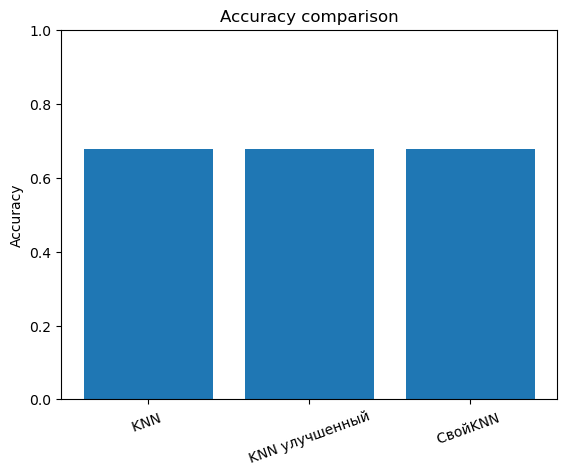

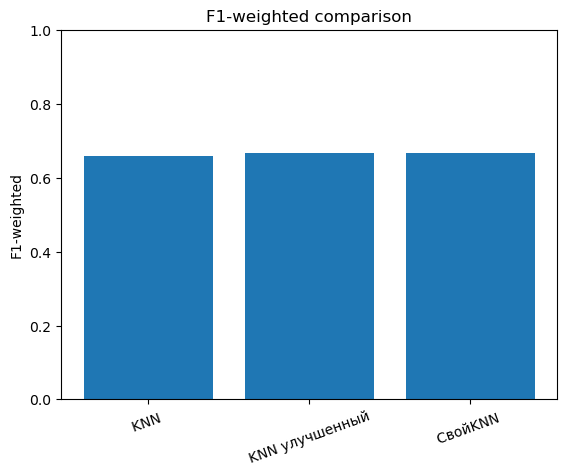

In [34]:
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "KNN ",
        "KNN улучшенный",
        "СвойKNN "
    ],
    "Accuracy": [
        accuracy_score(y_test, knn_baseline.predict(X_test_processed)),
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_my)
    ],
    "F1_weighted": [
        f1_score(y_test, knn_baseline.predict(X_test_processed), average="weighted"),
        f1_score(y_test, y_pred_best, average="weighted"),
        f1_score(y_test, y_pred_my, average="weighted")
    ]
})

display(results)

plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.title("Accuracy comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.bar(results["Model"], results["F1_weighted"])
plt.title("F1-weighted comparison")
plt.ylabel("F1-weighted")
plt.xticks(rotation= 20)
plt.ylim(0, 1)
plt.show()


In [ ]:
Регрессия

In [26]:
df_reg = pd.read_csv("mobile.csv") 
df_reg = df_reg.drop(columns=["Unnamed: 0"])

display(df_reg.head())

X = df_reg.drop(columns=["Price"])
y = df_reg["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


,Brand me,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999


MAE: 6979.73
MSE: 1213968445.70
R2 : 0.4779


In [ ]:
Ошибки неплохие , попробуем улучшить и подобрать переменные

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("knn", KNeighborsRegressor())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9,  11],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

grid_search = GridSearchCV(
    estimator= pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error", 
    n_jobs= -1
)

grid_search.fit(X_train, y_train)

print("лучшие получившиеся параметры")
print(grid_search.best_params_)
print(f"best MAE: {-grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print('\n'f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


лучшие получившиеся параметры
{'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}
best MAE: 4627.98

MAE: 2118.73
MSE: 107536133.92
R2 : 0.9537


In [ ]:
хначительное улучшение, mae значительно выросло
Далее реализация своего knn

In [25]:
class MyKNNRegressor:
    def __init__(self, n_neighbors=3, weights="distance", p=1):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.p = p

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        return self

    def _distance(self, x):
        if self.p == 1:
            return np.sum(np.abs(self.X_train - x), axis=1)
        else:
            return np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

    def _predict_one(self, x):
        distances = self._distance(x)
        idx = np.argsort(distances)[:self.n_neighbors]

        values = self.y_train[idx]
        dists = distances[idx]

        if self.weights == "distance":
            weights = 1 / (dists + 1e-8)
            return np.sum(weights * values) / np.sum(weights)
        else:
            return np.mean(values)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x) for x in X])

X_train_proc = best_model.named_steps["preprocessor"].transform(X_train).toarray()
X_test_proc  = best_model.named_steps["preprocessor"].transform(X_test).toarray()

my_knn_reg = MyKNNRegressor(
    n_neighbors=3,
    weights="distance",
    p=1
)

my_knn_reg.fit(X_train_proc, y_train)

y_pred_my = my_knn_reg.predict(X_test_proc)

mae = mean_absolute_error(y_test, y_pred_my)
mse = mean_squared_error(y_test, y_pred_my)
r2 = r2_score(y_test, y_pred_my)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 : {r2:.4f}")


MAE: 2118.92
MSE: 107534097.72
R2 : 0.9537


In [ ]:
неплохой результат, схожий с улучшенным knn